# InPCA embedding grouped by `bsel`

This notebook reproduces the two interactive 3D embedding plots using the outputs from `run_dataset_pipeline.py`, but colors points by **`bsel` (method)** instead of **`m` (architecture)**.

It makes two plots:
- Train embedding (`yh`)
- Val embedding (`yvh`)

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Make repo imports work whether you run from repo root or notebooks/
cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "utils").exists() else (cwd.parent if (cwd.parent / "utils").exists() else cwd)
sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import torch as th
from utils import CDICT_BSEL
from utils.plot import plotly_3d

In [2]:
# --- Config (edit these) ---
DATASET = 'CIFAR3'
INPCA_ROOT = repo_root / 'inpca_results' / DATASET
JOIN_FN = 'all_geod'
SEED = 16

print('INPCA_ROOT:', INPCA_ROOT)
print('Seed folder exists:', (INPCA_ROOT / str(SEED)).exists())


INPCA_ROOT: /home/lgreen/projects/low-dimensional-deepnets/inpca_results/CIFAR3
Seed folder exists: True


In [3]:
def _load_projection_and_index(key: str):
    key = str(key)
    fn = f"{key}_{JOIN_FN}"

    # r contains 'xp' (embedding coordinates) and 'e' (eigs)
    r_path = INPCA_ROOT / str(SEED) / f"r_{fn}_all.p"
    didx_path = INPCA_ROOT / str(SEED) / f"didx_{fn}.p"

    if not r_path.exists():
        raise FileNotFoundError(f"Missing projection file: {r_path}")
    if not didx_path.exists():
        raise FileNotFoundError(f"Missing index file: {didx_path}")

    r = th.load(str(r_path), weights_only=False)
    idx, didx = th.load(str(didx_path), weights_only=False)
    didx = didx.reset_index(drop=True)

    # Ensure bsel exists (it should if you grouped by bsel during distance computation)
    if "bsel" not in didx.columns:
        raise KeyError(f"'bsel' missing from didx columns: {list(didx.columns)}")

    # Guarantee we have m even if runs used 'model' key
    if "m" not in didx.columns and "model" in didx.columns:
        didx = didx.assign(m=didx["model"])

    return r, didx


def _make_bsel_cdict(values: pd.Series) -> dict:
    """Stable mapping: use CDICT_BSEL for known methods; deterministic fallback otherwise."""

    uniq = list(pd.Series(values).astype(str).unique())

    cdict = {k: CDICT_BSEL[k] for k in uniq if k in CDICT_BSEL}

    missing = sorted([k for k in uniq if k not in cdict])
    if missing:
        import seaborn as sns
        pal = sns.color_palette("Set2", n_colors=len(missing)).as_hex()
        for k, c in zip(missing, pal):
            cdict[k] = c

    return cdict


## Plot 1 — Train embedding (`yh`) colored by `bsel`

In [4]:
r_yh, didx_yh = _load_projection_and_index('yh')

cdict_bsel = _make_bsel_cdict(didx_yh['bsel'])

hover_cols = [c for c in ['bsel','m','seed','opt','bs','lr','wd','ratio','t','err','verr'] if c in didx_yh.columns]

fig = plotly_3d(
    didx_yh.reset_index(drop=True),
    r=r_yh,
    color='bsel',
    discrete_c=True,
    cdict=cdict_bsel,
    cols=hover_cols,
    size=4,
    opacity=0.85,
    xrange=[-3, 3],
    yrange=[-3, 3],
    zrange=[-3, 3],
)

fig.update_layout(title='Train (yh) embedding colored by bsel')

fig.show()


[ 86.97722703 -78.25715543  44.96033895  31.89991944 -15.83665325
  13.02829834  -4.16031719  -3.56343029  -2.11691305]


## Plot 2 — Val embedding (`yvh`) colored by `bsel`

In [5]:
r_yvh, didx_yvh = _load_projection_and_index('yvh')

cdict_bsel_v = _make_bsel_cdict(didx_yvh['bsel'])

hover_cols = [c for c in ['bsel','m','seed','opt','bs','lr','wd','ratio','t','err','verr'] if c in didx_yvh.columns]

fig = plotly_3d(
    didx_yvh.reset_index(drop=True),
    r=r_yvh,
    color='bsel',
    discrete_c=True,
    cdict=cdict_bsel_v,
    cols=hover_cols,
    size=4,
    opacity=0.85,
    xrange=[-3, 3],
    yrange=[-3, 3],
    zrange=[-3, 3],
)

fig.update_layout(title='Val (yvh) embedding colored by bsel')

fig.show()


[ 82.16087882 -78.31222818  45.73477335  31.18225224 -15.66112227
  12.87360828  -4.24532695  -3.65515968  -1.98653156]


Subsample file not found. Checked:
 - /home/lgreen/projects/low-dimensional-deepnets/notebooks/data/train_subsample_err_all.p
 - /home/lgreen/projects/low-dimensional-deepnets/data/train_subsample_err_all.p
 - /home/lgreen/projects/low-dimensional-deepnets/CIFAR3/train_subsample_err_all.p
 - /home/lgreen/projects/low-dimensional-deepnets/inpca_results/CIFAR3/16/train_subsample_err_all.p


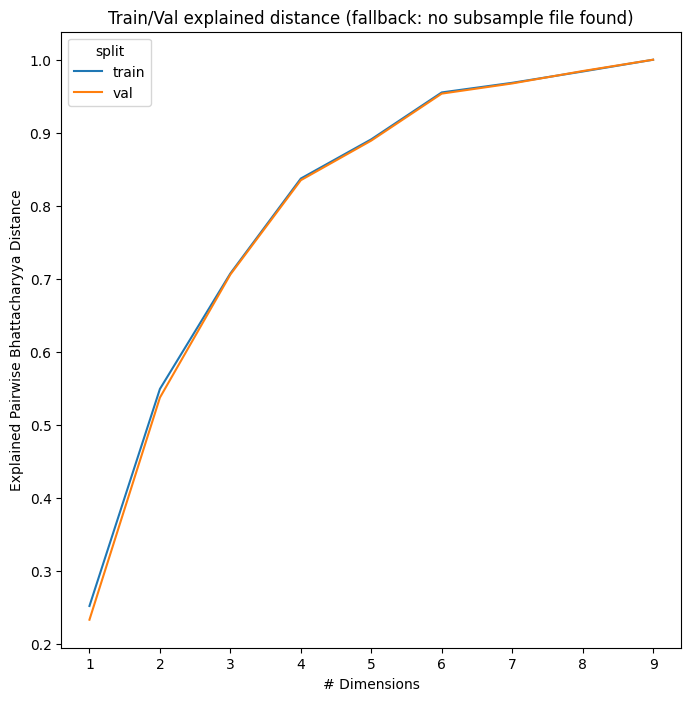

In [6]:
# Plot 3 — Explained pairwise Bhattacharyya distance vs dimensions
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from utils.embed import explained_stress

fn = 'train'  # set to 'test' to prefer test subsample file if available

# Try the legacy subsample files first (as in subset_embedding.ipynb).
candidate_roots = [
    repo_root / 'notebooks' / 'data',
    repo_root / 'data',
    repo_root / DATASET,
    INPCA_ROOT / str(SEED),
]

subsample_path = None
for root in candidate_roots:
    p = root / f'{fn}_subsample_err_all.p'
    if p.exists():
        subsample_path = p
        break

if subsample_path is not None:
    rel_error_all_ = pickle.load(open(subsample_path, 'rb'))
    ns = [10, 100, 1000] if fn == 'test' else [50, 500, 5000]

    ds = pd.DataFrame(rel_error_all_[ns[0]].T[:, [0, -1]], columns=['dimension', 4])
    ds = ds.reset_index(drop=True).melt(id_vars='dimension')
    for i, s in enumerate(ns):
        tmp = rel_error_all_[s]
        tmp_ds = pd.DataFrame(tmp.T[:, :2], columns=['dimension', i])
        tmp_ds = tmp_ds.reset_index().melt(id_vars='dimension', value_vars=[i])
        ds = pd.concat([ds, tmp_ds], ignore_index=True)

    f, ax = plt.subplots(figsize=(8, 8))
    ylims = (0.5, 0.86) if fn == 'train' else (0.13, 0.58)
    sns.lineplot(data=ds, x='dimension', y='value', hue='variable', ax=ax)
    legend_handles, _ = ax.get_legend_handles_labels()
    ax.legend(legend_handles, [f'N = {s}' for s in ns] + ['Original'], loc='lower right')
    ax.set(
        ylim=ylims,
        xlabel='# Dimensions',
        ylabel='Explained Pairwise Bhattacharyya Distance',
    )
    ax.set_title(f"{fn.capitalize()} split (subsampled)")
    print(f'Loaded subsample data from: {subsample_path}')
else:
    # Fallback: always available with current notebook state.
    curves = []
    for split_name, r_cur in [('train', r_yh), ('val', r_yvh)]:
        expl = np.asarray(explained_stress(r_cur))
        curves.append(pd.DataFrame({
            'dimension': np.arange(1, len(expl) + 1),
            'value': expl,
            'split': split_name,
        }))
    ds_fallback = pd.concat(curves, ignore_index=True)

    f, ax = plt.subplots(figsize=(8, 8))
    sns.lineplot(data=ds_fallback, x='dimension', y='value', hue='split', ax=ax)
    ax.set(
        xlabel='# Dimensions',
        ylabel='Explained Pairwise Bhattacharyya Distance',
    )
    ax.set_title('Train/Val explained distance (fallback: no subsample file found)')
    print('Subsample file not found. Checked:')
    for root in candidate_roots:
        print(' -', root / f'{fn}_subsample_err_all.p')

In [7]:
from copy import deepcopy

def _filter_by_opt(didx, r, opt_name="adamw"):
    # Case-insensitive match in case values are "adamw", "AdamW", etc.
    mask = didx["opt"].astype(str).str.lower().eq(opt_name.lower()).to_numpy()
    didx_f = didx.loc[mask].reset_index(drop=True)

    r_f = deepcopy(r)
    r_f["xp"] = r["xp"][mask]
    return didx_f, r_f

# Train
didx_yh_adamw, r_yh_adamw = _filter_by_opt(didx_yh, r_yh, "adam")
fig = plotly_3d(
    didx_yh_adamw,
    r=r_yh_adamw,
    color="bsel",
    discrete_c=True,
    cdict=_make_bsel_cdict(didx_yh_adamw["bsel"]),
    cols=[c for c in ['bsel','m','seed','opt','bs','lr','wd','ratio','t','err','verr'] if c in didx_yh_adamw.columns],
    size=4,
    opacity=0.85,
    xrange=[-3, 3],
    yrange=[-3, 3],
    zrange=[-3, 3],
)
fig.update_layout(title="Train (yh) embedding colored by bsel — opt=adamw")
fig.show()

# Val
didx_yvh_adamw, r_yvh_adamw = _filter_by_opt(didx_yvh, r_yvh, "adam")
fig = plotly_3d(
    didx_yvh_adamw,
    r=r_yvh_adamw,
    color="bsel",
    discrete_c=True,
    cdict=_make_bsel_cdict(didx_yvh_adamw["bsel"]),
    cols=[c for c in ['bsel','m','seed','opt','bs','lr','wd','ratio','t','err','verr'] if c in didx_yvh_adamw.columns],
    size=4,
    opacity=0.85,
    xrange=[-3, 3],
    yrange=[-3, 3],
    zrange=[-3, 3],
)
fig.update_layout(title="Val (yvh) embedding colored by bsel — opt=adamw")
fig.show()

[ 86.97722703 -78.25715543  44.96033895  31.89991944 -15.83665325
  13.02829834  -4.16031719  -3.56343029  -2.11691305]


[ 82.16087882 -78.31222818  45.73477335  31.18225224 -15.66112227
  12.87360828  -4.24532695  -3.65515968  -1.98653156]


No external original progress file with f/fv was found.


Missing loss columns in current dataset: ['f', 'fv']
Rows plotted: 828 | Methods: ['Bayesian', 'DivBS', 'Full', 'GradNorm', 'RhoLoss', 'Uniform']


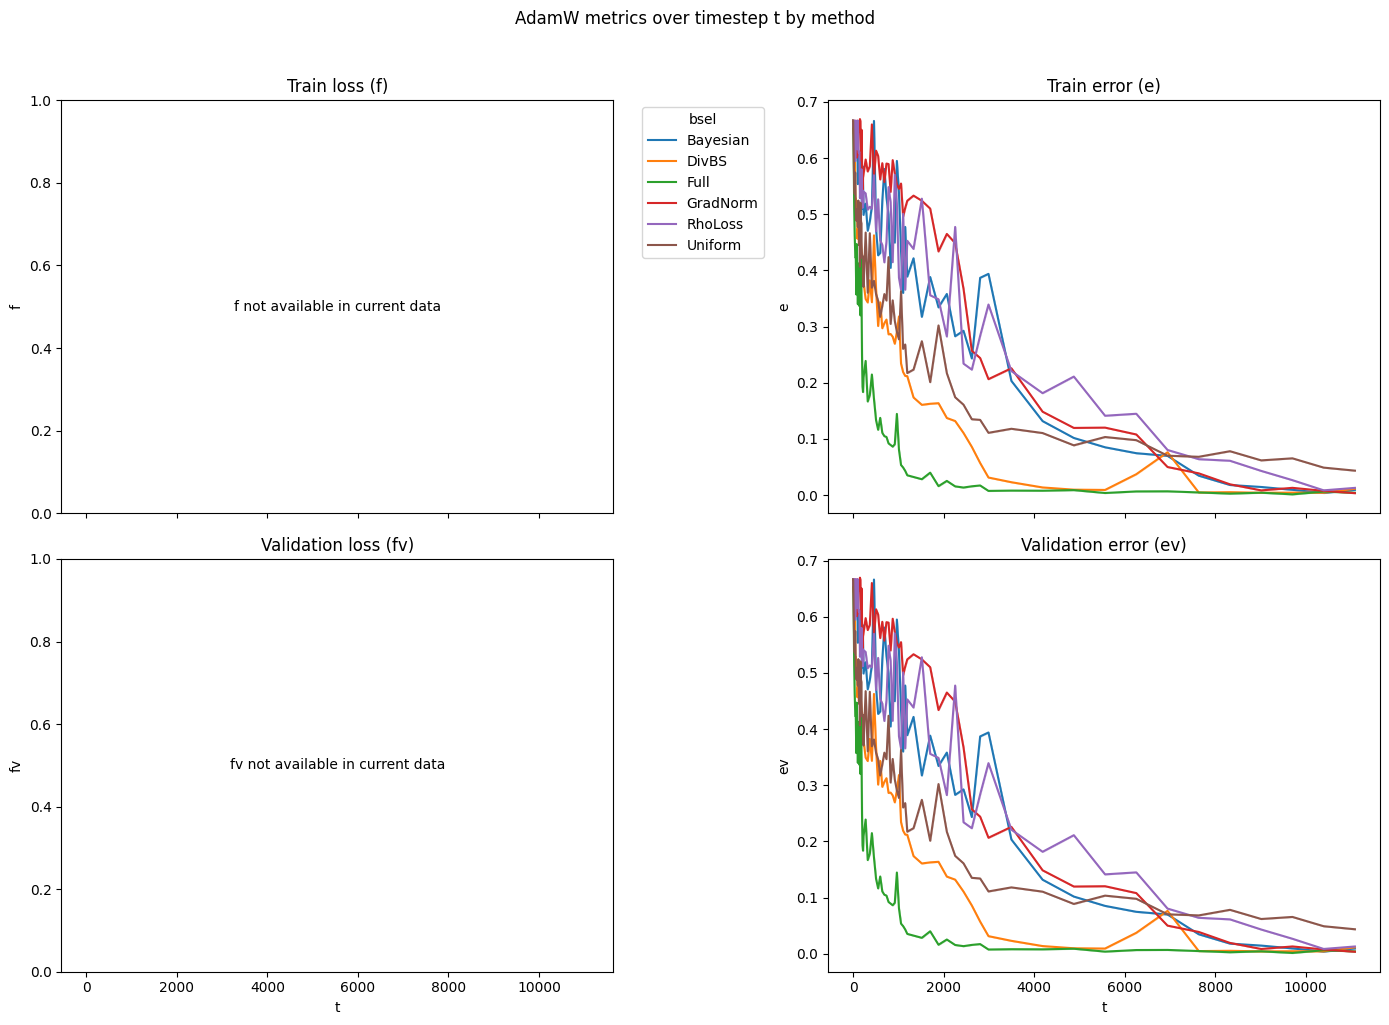

In [8]:
# Plot 4 — AdamW metrics over timestep t by method (bsel)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Optional: point this to the original progress file that contains f/fv.
# Example: Path('/home/ubuntu/ext_vol/inpca/inpca_results_all/didx_geod_all_progress.p')
ORIG_PROGRESS_PATH = '/home/lgreen/projects/low-dimensional-deepnets/inpca_results/CIFAR10/didx_geod_all_progress.p'

def _load_didx_df(path: Path):
    obj = th.load(str(path), weights_only=False)
    if isinstance(obj, pd.DataFrame):
        return obj
    if isinstance(obj, (tuple, list)):
        for x in obj[::-1]:
            if isinstance(x, pd.DataFrame):
                return x
    return None

# Combine train/val metadata so we can plot train + validation metrics together.
df = didx_yh.copy().reset_index(drop=True)
df_val = didx_yvh.copy().reset_index(drop=True)

# Bring validation metrics into the same frame when available.
if 'f' in df_val.columns and 'fv' not in df.columns:
    df['fv'] = df_val['f'].values
if 'e' in df_val.columns and 'ev' not in df.columns:
    df['ev'] = df_val['e'].values
if 'err' in df_val.columns and 'ev' not in df.columns:
    df['ev'] = df_val['err'].values
if 'verr' in df_val.columns and 'ev' not in df.columns:
    df['ev'] = df_val['verr'].values

# Support both naming conventions: e/ev and err/verr.
if 'e' not in df.columns and 'err' in df.columns:
    df['e'] = df['err']
if 'ev' not in df.columns and 'verr' in df.columns:
    df['ev'] = df['verr']

# If f/fv are missing, try to recover them from an original progress file.
if 'f' not in df.columns or 'fv' not in df.columns:
    candidate_paths = [
        ORIG_PROGRESS_PATH,
        repo_root / DATASET / 'didx_geod_all_progress.p',
        INPCA_ROOT / 'didx_geod_all_progress.p',
        Path('/home/lgreen/projects/low-dimensional-deepnets/inpca_results/CIFAR10/didx_geod_all_progress.p'),
    ]

    source_df = None
    source_path = None
    for p in candidate_paths:
        if p is None:
            continue
        p = Path(p)
        if not p.exists():
            continue
        tmp = _load_didx_df(p)
        if tmp is None:
            continue
        if ('f' in tmp.columns) or ('fv' in tmp.columns):
            source_df = tmp.copy()
            source_path = p
            break

    if source_df is not None:
        merge_keys_pref = ['seed', 'm', 'opt', 't', 'bs', 'lr', 'wd', 'bsel', 'ratio']
        merge_keys = [k for k in merge_keys_pref if k in df.columns and k in source_df.columns]
        if merge_keys:
            keep_cols = merge_keys + [c for c in ['f', 'fv'] if c in source_df.columns]
            source_df = source_df[keep_cols].copy()
            df = df.merge(source_df, how='left', on=merge_keys, suffixes=('', '_orig'))
            print(f'Loaded loss columns from: {source_path}')
        else:
            print('Found original progress file with loss columns, but no compatible merge keys.')
    else:
        print('No external original progress file with f/fv was found.')

# Accept alternative loss column names if present.
loss_train_candidates = ['f', 'loss', 'train_loss']
loss_val_candidates = ['fv', 'val_loss', 'validation_loss']

train_loss_col = next((c for c in loss_train_candidates if c in df.columns), None)
val_loss_col = next((c for c in loss_val_candidates if c in df.columns), None)

# Filter optimizer: prefer exact adamw; fallback to any 'adam*' if no exact match.
opt_series = df['opt'].astype(str).str.lower()
mask = opt_series.eq('adamw')
if mask.sum() == 0:
    mask = opt_series.str.startswith('adam')
    print("No exact 'adamw' rows found; using optimizer rows starting with 'adam'.")

df_opt = df.loc[mask].copy()

required_base = ['t', 'bsel', 'e', 'ev']
missing_base = [c for c in required_base if c not in df_opt.columns]
if missing_base:
    raise KeyError(f"Missing required columns for error plots: {missing_base}. Available columns: {list(df_opt.columns)}")

# Build plotting frame with canonical names expected in the figure.
plot_df = df_opt[['t', 'bsel', 'e', 'ev']].copy()
if train_loss_col is not None:
    plot_df['f'] = df_opt[train_loss_col]
if val_loss_col is not None:
    plot_df['fv'] = df_opt[val_loss_col]

for c in ['t', 'e', 'ev', 'f', 'fv']:
    if c in plot_df.columns:
        plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

drop_subset = ['t', 'e', 'ev'] + ([c for c in ['f', 'fv'] if c in plot_df.columns])
plot_df = plot_df.dropna(subset=drop_subset)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Train loss (f)
if 'f' in plot_df.columns:
    sns.lineplot(data=plot_df, x='t', y='f', hue='bsel', estimator='mean', errorbar='sd', ax=axes[0, 0])
else:
    axes[0, 0].text(0.5, 0.5, 'f not available in current data', ha='center', va='center', transform=axes[0, 0].transAxes)
axes[0, 0].set_title('Train loss (f)')
axes[0, 0].set_ylabel('f')

# Train error (e)
sns.lineplot(data=plot_df, x='t', y='e', hue='bsel', estimator='mean', errorbar='sd', ax=axes[0, 1])
axes[0, 1].set_title('Train error (e)')
axes[0, 1].set_ylabel('e')

# Validation loss (fv)
if 'fv' in plot_df.columns:
    sns.lineplot(data=plot_df, x='t', y='fv', hue='bsel', estimator='mean', errorbar='sd', ax=axes[1, 0])
else:
    axes[1, 0].text(0.5, 0.5, 'fv not available in current data', ha='center', va='center', transform=axes[1, 0].transAxes)
axes[1, 0].set_title('Validation loss (fv)')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('fv')

# Validation error (ev)
sns.lineplot(data=plot_df, x='t', y='ev', hue='bsel', estimator='mean', errorbar='sd', ax=axes[1, 1])
axes[1, 1].set_title('Validation error (ev)')
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('ev')

# Keep one legend and remove duplicates from the other axes.
legend_source = axes[0, 1]
handles, labels = legend_source.get_legend_handles_labels()
axes[0, 0].legend(handles, labels, title='bsel', bbox_to_anchor=(1.04, 1), loc='upper left')
for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig.suptitle('AdamW metrics over timestep t by method', y=1.02)
fig.tight_layout()
missing_msgs = []
if 'f' not in plot_df.columns:
    missing_msgs.append('f')
if 'fv' not in plot_df.columns:
    missing_msgs.append('fv')
if missing_msgs:
    print(f"Missing loss columns in current dataset: {missing_msgs}")
print(f"Rows plotted: {len(plot_df)} | Methods: {sorted(plot_df['bsel'].astype(str).unique())}")